# Семинар 2. Введение в инструменты визуализации

На этом семинаре мы познакомимся с двумя основными библиотеками для визуализации данных в Python: `matplotlib` и `seaborn`.

Для начала импортируем необходимые библиотеки:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


## 1. Базовые графики в Matplotlib

Начнем с самого простого. У нас есть массивы значений $x$ и $y$, и мы хотим построить линейный график. В `matplotlib.pyplot` (который мы импортировали как `plt`) за это отвечает функция `plot()`. В качестве первого аргумента она принимает массив значений по оси х, а в качестве второго — по оси у.


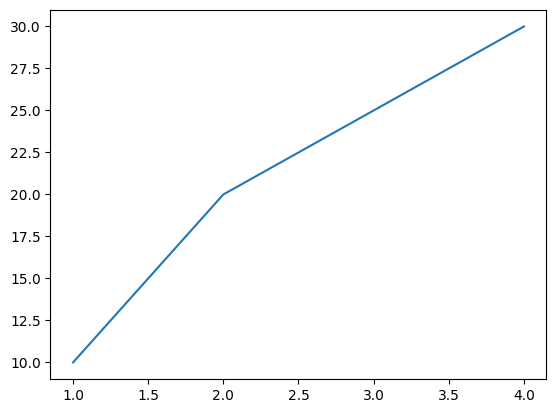

In [2]:
x = [1, 2, 3, 4]
y = [10, 20, 25, 30]

plt.plot(x, y)


Если нам нужны точки, а не соединенная линия, мы можем использовать функцию `plt.scatter()`:


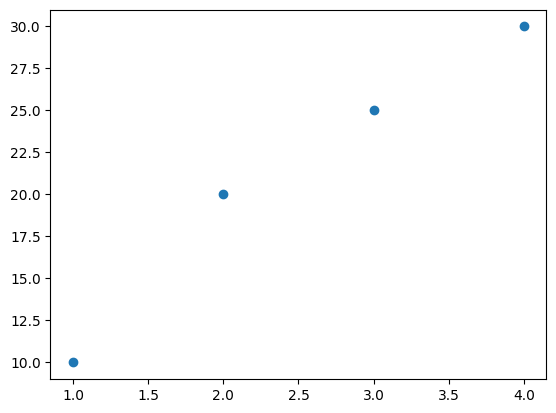

In [3]:
plt.scatter(x, y)


Или столбчатую диаграмму (`plt.bar()`):


<BarContainer object of 4 artists>

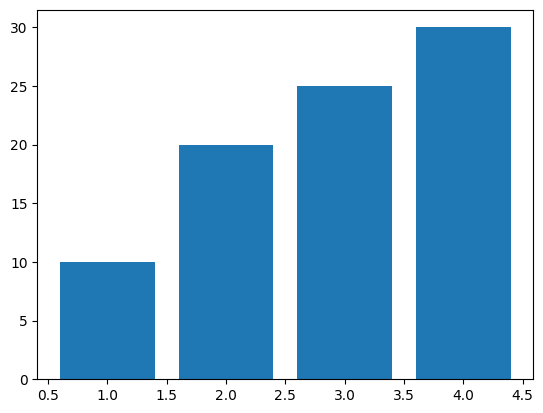

In [4]:
plt.bar(x, y)


Или круговую диаграмму (`plt.pie()`):


In [ ]:
plt.pie(y)


## 2. Объектно-ориентированный подход в Matplotlib

Выше мы использовали простой "state-machine" подход: мы просто вызывали функции из `plt`, и Matplotlib сам рисовал их на "текущем" графике.
Но для создания сложных композиций графиков лучше использовать **объектно-ориентированный подход**.

В основе любой картинки в `matplotlib` лежит объект `Figure`. По сути, это холст, на котором мы будем рисовать.


In [6]:
fig = plt.figure(figsize=(9, 6))


<Figure size 900x600 with 0 Axes>

Выше мы создали пустую область (Figure) размером 9 на 6 дюймов. Пока на ней ничего нет.
Чтобы что-то нарисовать, нам нужно добавить на нее оси — объект `Axes`. Это система координат, в которой будут строиться наши данные.


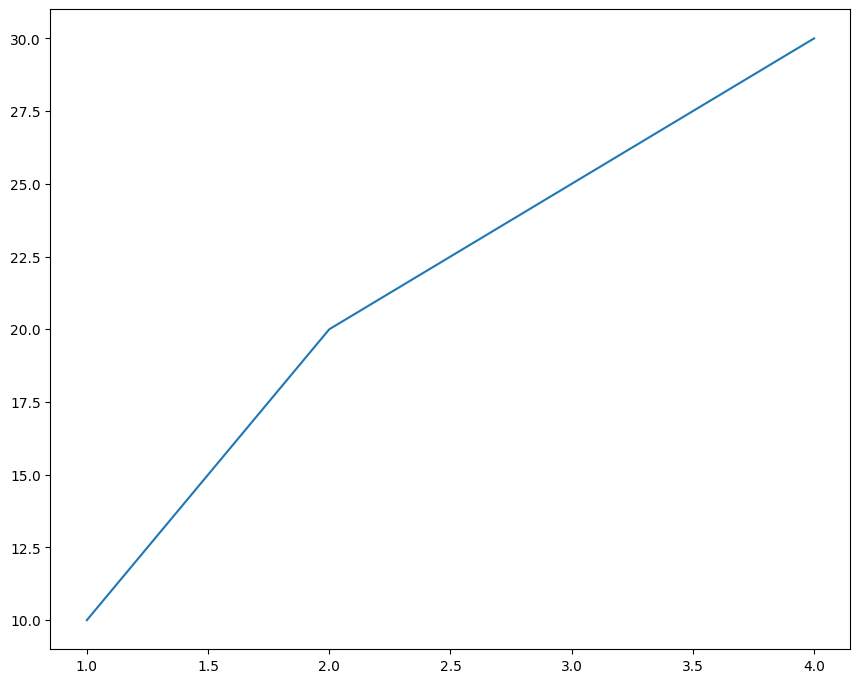

In [7]:
fig = plt.figure(figsize=(10, 8))
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8]) # [left, bottom, width, height] в долях от Figure
ax1.plot(x, y)


На одной `Figure` можно разместить несколько `Axes`.


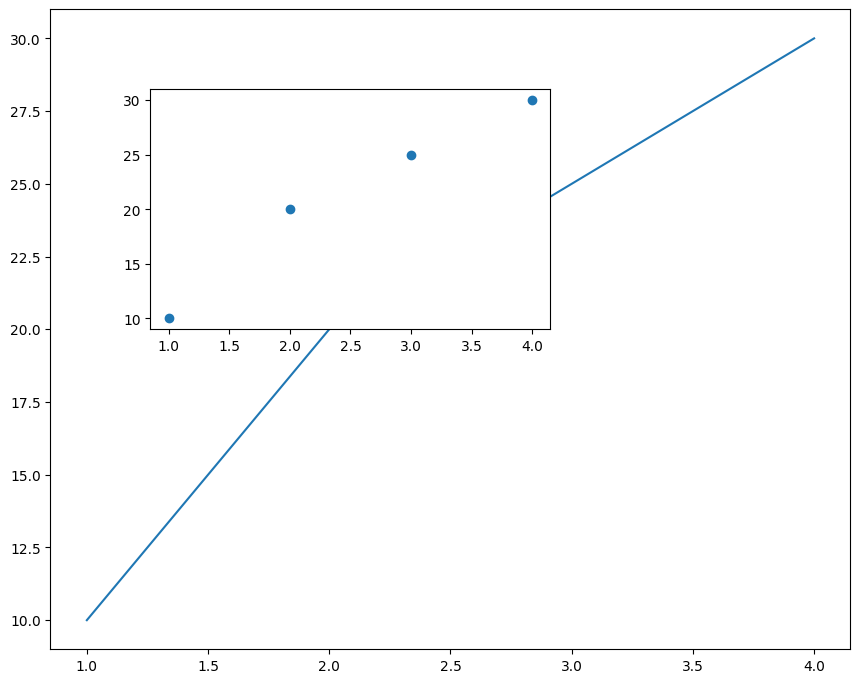

In [8]:
fig = plt.figure(figsize=(10, 8))
# Основной график
ax1 = fig.add_axes([0.1, 0.1, 0.8, 0.8])
# Вложенный график
ax2 = fig.add_axes([0.2, 0.5, 0.4, 0.3])

ax1.plot(x, y)
ax2.scatter(x, y)


### Функция plt.subplots()

Создавать графики через `add_axes` вручную довольно утомительно. Гораздо удобнее использовать функцию `plt.subplots()`. Она возвращает сразу `Figure` и массив из нужного количества `Axes`.


([<matplotlib.patches.Wedge at 0x7b1737386b70>,
 [Text(1.0257194531341634, 0.3973658307682647, ''),
  Text(0.10149520411299703, 1.0953075931180525, ''),
  Text(-1.0999999999999959, -9.616505800409723e-08, ''),
  Text(0.49031222266058644, -0.9846796049018359, '')])

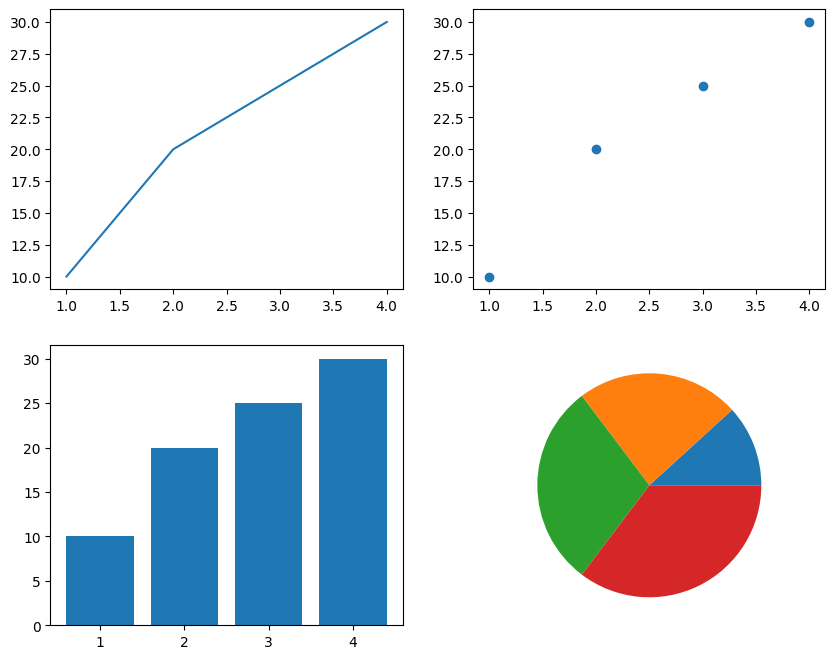

In [9]:
# Создаем сетку из 4 графиков: 2 строки, 2 столбца
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Теперь axes — это матрица 2x2. Мы можем обращаться к каждому графику по индексам
axes[0, 0].plot(x, y)
axes[0, 1].scatter(x, y)
axes[1, 0].bar(x, y)
axes[1, 1].pie(y)


Если у всех графиков одинаковые шкалы (например, одна и та же ось времени), можно не загромождать картинку повторяющимися цифрами на осях, а использовать параметры `sharex=True` и `sharey=True`.


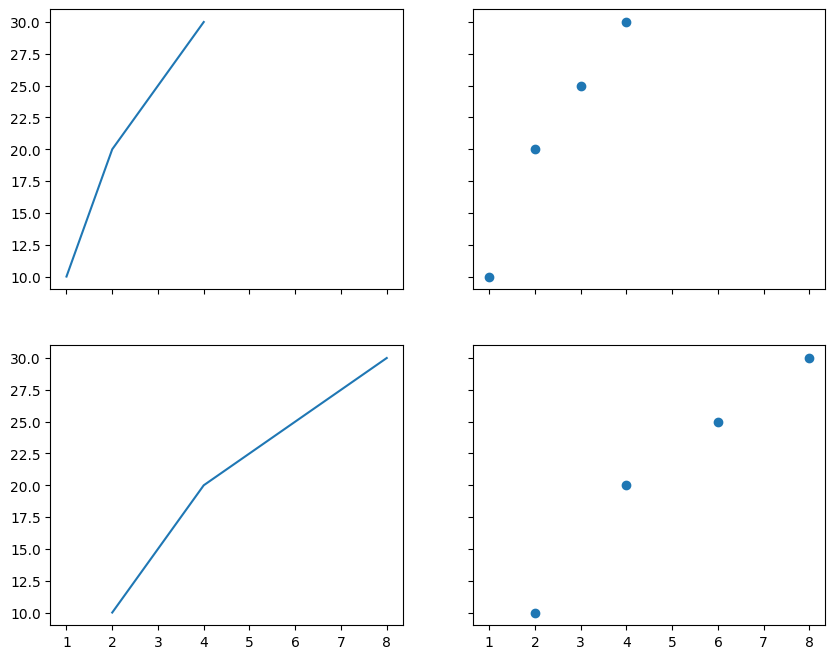

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)

axes[0, 0].plot(x, y)
axes[0, 1].scatter(x, y)
axes[1, 0].plot(np.array(x)*2, y)
axes[1, 1].scatter(np.array(x)*2, y)


У объекта `ax` можно полностью отключить отображение осей с помощью метода `ax.axis('off')`. Это особенно полезно при выводе картинок (например, обложек музыкальных альбомов!).


(np.float64(-0.5), np.float64(4166.5), np.float64(4166.5), np.float64(-0.5))

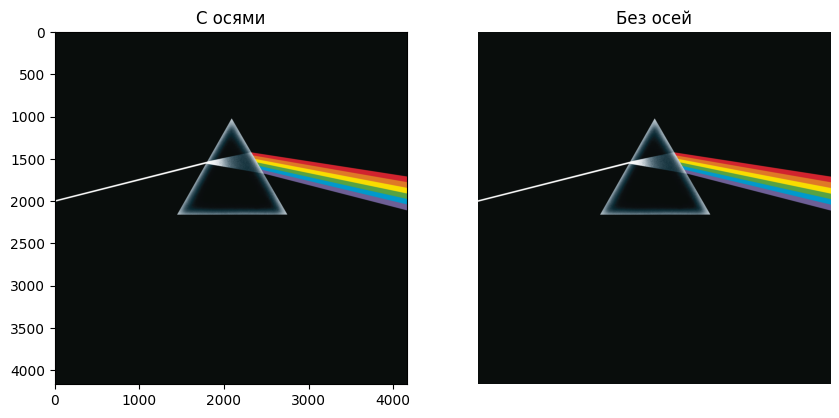

In [11]:
import urllib.request
from PIL import Image

# Скачиваем обложку Pink Floyd для примера
url = "https://upload.wikimedia.org/wikipedia/en/3/3b/Dark_Side_of_the_Moon.png"
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as response:
    img = np.array(Image.open(response).convert('RGB'))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# С осями (по умолчанию)
axes[0].imshow(img)
axes[0].set_title('С осями')

# Без осей
axes[1].imshow(img)
axes[1].set_title('Без осей')
axes[1].axis('off')


---
## 3. Библиотека Seaborn: Кратко про более сложные виды графиков

`seaborn` — это библиотека, построенная поверх `matplotlib`. Она позволяет строить красивые и сложные статистические графики минимальным количеством кода.

В качестве примера загрузим датасет треков Spotify. Это отличный датасет для изучения многомерных связей.


In [12]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-01-21/spotify_songs.csv"
spotify = pd.read_csv(url)

# Для быстроты отрисовки возьмем случайную выборку
spotify_sample = spotify.sample(3000, random_state=42).copy()
spotify_sample.head(3)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
30056,697MjF1454XKvZmTuqkWmD,I Miss You,Jeriqo,45,2vJ6FDg6ZMS56U8Wbiw2Oz,I Miss You,2019-02-05,Pop Hits 2000-2019,6mtYuOxzl58vSGnEDtZ9uB,edm,...,0,-7.717,1,0.0432,0.00491,0.000013,0.0816,0.415,174.026,216347
11827,3x2bXiU0o4WbsPkawXlfDA,Who Are You,The Who,17,6LRJF97hgXHj8uMLHyCDbh,Who Are You (Remastered),1978-08-18,House Of The Rising Sun,1bMYfBHYBCRHY5LGkjlpSy,rock,...,9,-11.405,1,0.0511,0.26500,0.003130,0.1060,0.489,156.371,378707
23571,0jEaPBjFAWjQTMVouRwaHi,Happy,The Beef Seeds,30,4IQn9XpweytNX2cUe2NBUH,Keepin' it Beefy,2015-01-19,Bluegrass Covers,37i9dQZF1DX56crgoe4TG3,r&b,...,10,-5.204,1,0.1600,0.66500,0.000000,0.1270,0.932,86.529,218044


### Некоторые возможности метода sns.relplot

Метод `relplot` используется для отображения статистических взаимосвязей (scatter и line plots).


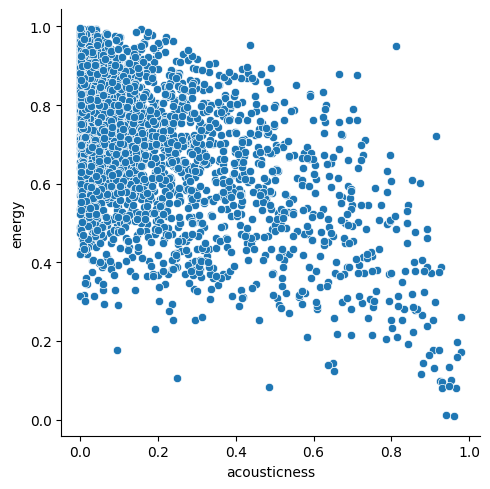

In [13]:
sns.relplot(
    data=spotify_sample,
    x='acousticness',
    y='energy'
)


Цвет по умолчанию один и тот же для всех точек. Но с помощью параметра `hue` можно раскрасить их в зависимости от категориального признака (например, жанра `playlist_genre`).


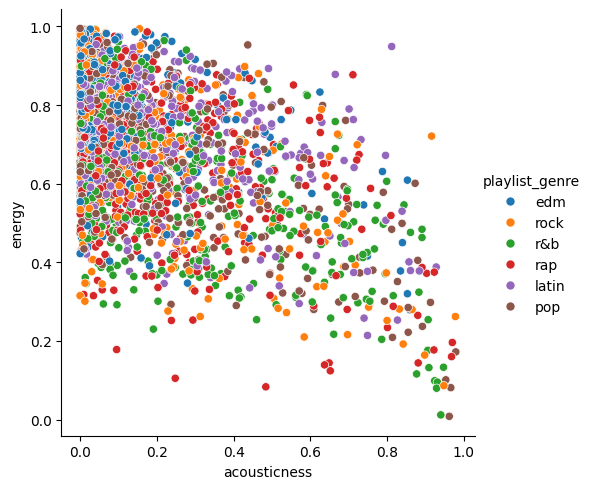

In [14]:
sns.relplot(
    data=spotify_sample,
    x='acousticness',
    y='energy',
    hue='playlist_genre'
)


### Линейные графики в relplot

Другой тип графика в `relplot` — линейный (`kind='line'`). Посмотрим на зависимость параметров треков от года выпуска.
Сначала извлечем год из даты.


In [28]:
spotify_sample['year'] = pd.to_datetime(spotify_sample['track_album_release_date'], format = 'mixed').dt.year
# Оставим только треки после 1980 года для наглядности
spotify_recent = spotify_sample[spotify_sample['year'] > 1980]
spotify_recent

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,year
30056,697MjF1454XKvZmTuqkWmD,I Miss You,Jeriqo,45,2vJ6FDg6ZMS56U8Wbiw2Oz,I Miss You,2019-02-05,Pop Hits 2000-2019,6mtYuOxzl58vSGnEDtZ9uB,edm,...,-7.717,1,0.0432,0.004910,0.000013,0.0816,0.415,174.026,216347,2019
23571,0jEaPBjFAWjQTMVouRwaHi,Happy,The Beef Seeds,30,4IQn9XpweytNX2cUe2NBUH,Keepin' it Beefy,2015-01-19,Bluegrass Covers,37i9dQZF1DX56crgoe4TG3,r&b,...,-5.204,1,0.1600,0.665000,0.000000,0.1270,0.932,86.529,218044,2015
14741,5EKUb1FKsyYVaSXb41YBIj,ONE,Rev Theory,35,0gGic19XvEiHKKWBV7M4YM,ONE,2020-01-15,Rock Hard,37i9dQZF1DWWJOmJ7nRx0C,rock,...,-2.352,0,0.0453,0.000006,0.000000,0.3030,0.520,90.016,208196,2020
25570,300DUx4tdtCdGEUXR032jA,Palace/Curse,The Internet,62,69g3CtOVg98TPOwqmI2K7Q,Ego Death,2015-06-26,NEO-soul,3q3M4VCymcMoxJ3Tl7mRqN,r&b,...,-8.212,0,0.3230,0.035100,0.000727,0.2430,0.261,67.104,440013,2015
8886,1itdjHXFxPQUje5AsI5e9P,Hände hoch,Baba Saad,22,474520Emg4GhbVg9rmqfib,Hände hoch,2017-11-06,Gangster Rap Deutsch,1qXg9ck25tBRxeXsj8mbDG,rap,...,-6.662,1,0.3840,0.145000,0.000000,0.3830,0.498,91.113,154768,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32182,14BmGOdWFMkxiyQ7f4s03L,Here With Me (feat. Nevve),ARMNHMR,38,4cBVizWVamVwH4v5g6zTto,Here With Me (feat. Nevve),2020-01-17,Brand New EDM,2dNitDEHM9FpUGEHWc7zyW,edm,...,-4.443,1,0.0406,0.120000,0.000000,0.2740,0.346,145.024,205241,2020
6346,1KKayLqz1vq8jdyRiYSVyx,Flytilstand,Benny Jamz,61,29GJOmCXgDETVLrfdZYdeJ,Flytilstand,2019-12-19,DK rap,37i9dQZF1DXdhDukKQ88Cc,rap,...,-4.504,0,0.0732,0.060800,0.000000,0.2620,0.329,99.991,147988,2019
18868,5Id5B3dxJZhPcV9GzgYZZe,Quizas,Rich Music LTD,88,1faqBAWocW4ZOe0OFjudGw,The Academy,2019-10-11,Reggaeton 2020 ☀,7xWuNevFBmwnFEg6wzdCc7,latin,...,-2.454,1,0.1530,0.025800,0.000000,0.2310,0.677,176.075,216067,2019
29567,3NcO4jGK1Opb5ea0mYLpxb,Good Feeling,Flo Rida,59,19JqA8H10co29VVwazL2Gw,Good Feeling,2011-08-29,@deniceemoberg EDM - POP REMIXES,2fbrY1tuoW8Uji14H7623k,edm,...,-4.444,0,0.0688,0.058800,0.002860,0.3060,0.684,128.011,248133,2011


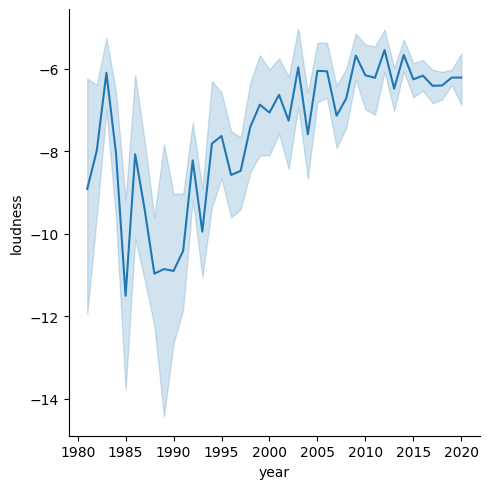

In [29]:
sns.relplot(
    data=spotify_recent,
    x='year',
    y='loudness',
    kind='line'
)


Как мы видим, одному году соответствует много разных треков с разной громкостью (`loudness`). `seaborn` по умолчанию строит линию по **среднему значению**, а закрашенная область — это **95% доверительный интервал** для среднего.

Мы можем отключить доверительный интервал (`errorbar=None`):


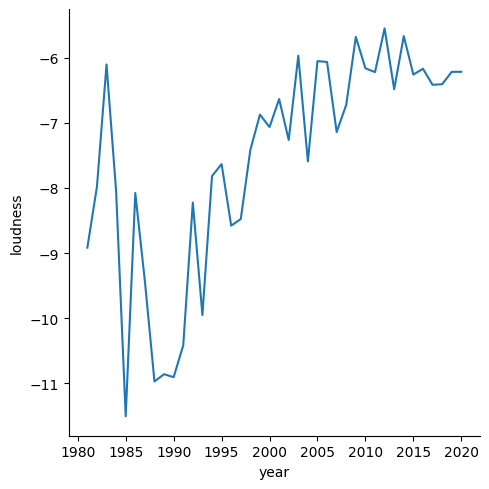

In [30]:
sns.relplot(
    data=spotify_recent,
    x='year',
    y='loudness',
    kind='line',
    errorbar=None
)


Или вместо него отобразить коридор стандартного отклонения (разброс значений):


In [ ]:
sns.relplot(
    data=spotify_recent,
    x='year',
    y='loudness',
    kind='line',
    errorbar='sd'
)


Аргументы `hue`, `col` и `row` работают тут точно так же, позволяя строить сетку графиков.


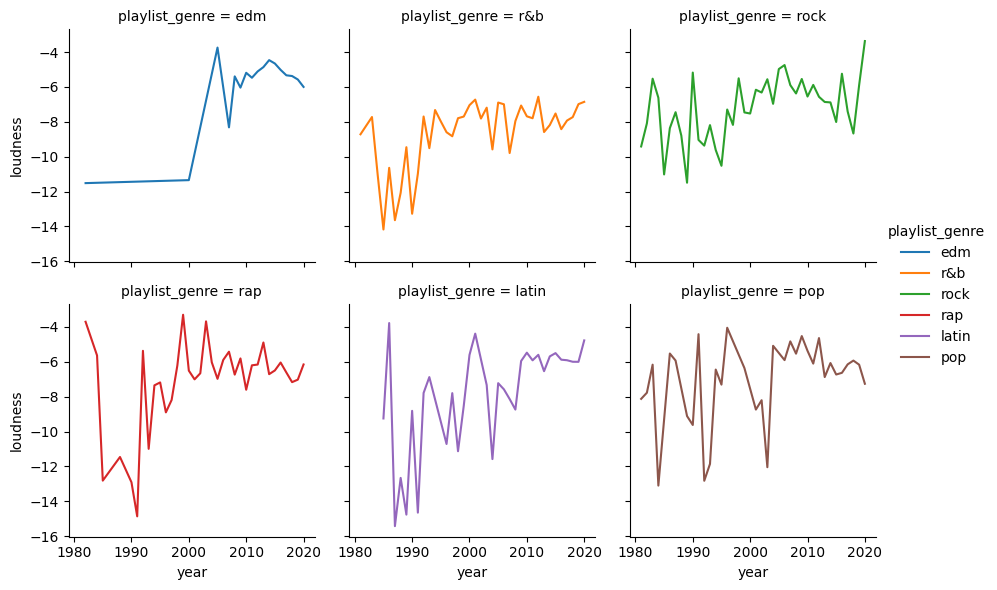

In [31]:
sns.relplot(
    data=spotify_recent,
    x='year',
    y='loudness',
    kind='line',
    errorbar=None,
    hue='playlist_genre',
    col='playlist_genre',
    col_wrap=3, # Переносить на новую строку после 3 колонок
    height=3
)


---
### 4. Тепловые карты (Heatmap)

Heatmap — это удобный способ визуализировать числовую матрицу цветом.
Сначала создадим сводную таблицу (pivot table). Посчитаем среднюю популярность треков (`track_popularity`) в зависимости от жанра (`playlist_genre`) и года выпуска.


In [32]:
# Сгруппируем года по десятилетиям для компактности
spotify_sample['decade'] = (spotify_sample['year'] // 10) * 10
pivot_pop = pd.pivot_table(
    data=spotify_sample,
    index='playlist_genre',
    columns='decade',
    values='track_popularity',
    aggfunc='mean'
)
pivot_pop


decade,1960,1970,1980,1990,2000,2010,2020
playlist_genre,,,,,,,
edm,NaN,NaN,31.000000,NaN,17.307692,36.066019,36.428571
latin,NaN,72.000000,38.200000,36.222222,32.887097,50.115681,54.888889
pop,NaN,75.000000,50.214286,46.285714,38.750000,48.874092,41.000000
r&b,48.333333,36.666667,35.357143,34.872093,31.666667,45.895753,52.083333
rap,53.000000,52.000000,51.666667,39.840000,32.635135,44.279793,47.312500
rock,58.777778,42.862500,42.179487,45.666667,43.210526,37.489796,45.750000


Для некоторых старых десятилетий и жанров данных может не быть (там стоит `NaN`). Посмотрим, как heatmap с этим справляется.


<Axes: xlabel='decade', ylabel='playlist_genre'>

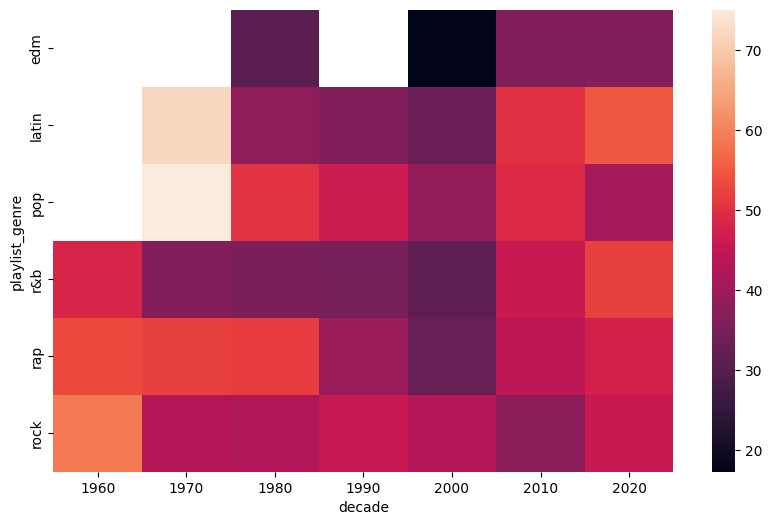

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_pop, ax=ax)


Ячейкам со значением `NaN` соответствуют белые (пустые) клетки. Чтобы сделать график информативнее, добавим числа (`annot=True`) и поменяем палитру (`cmap`).


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_pop, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)


Чаще всего `sns.heatmap` используют для визуализации **матрицы корреляций**.


Text(0.5, 1.0, 'Корреляция аудио-характеристик Spotify')

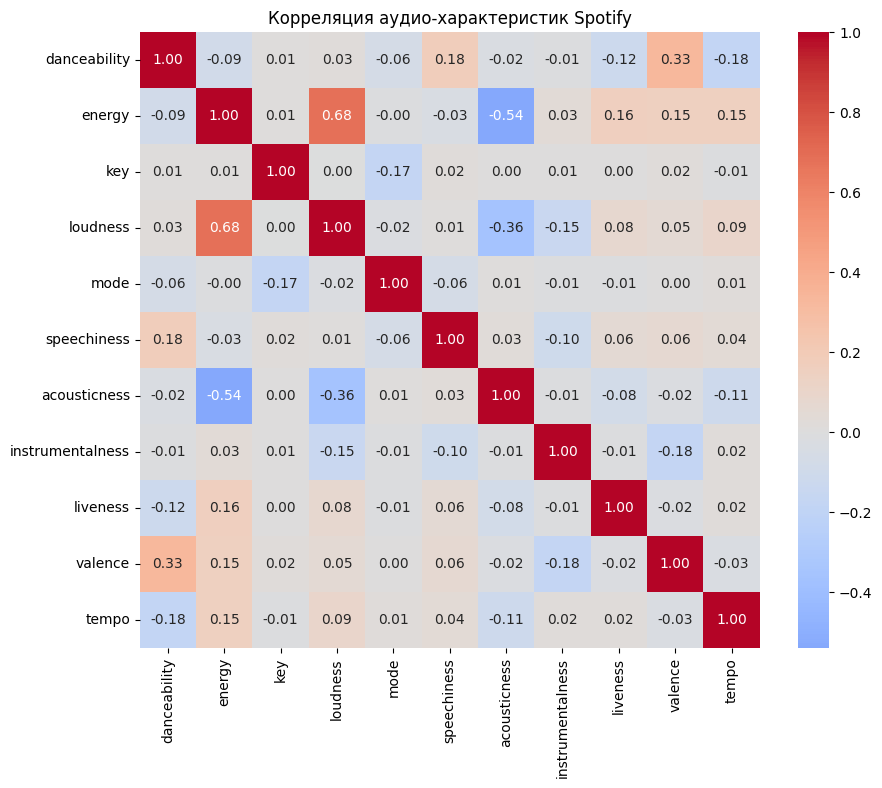

In [35]:
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
corr = spotify[audio_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
plt.title("Корреляция аудио-характеристик Spotify")


Здесь ярко-красный означает сильную положительную корреляцию (например, `energy` и `loudness`), а синий — отрицательную (например, `acousticness` и `energy`).


---
### 5. Гистограммы: histplot и displot

Посмотрим на распределение темпа (`tempo`).


<Axes: xlabel='tempo', ylabel='Count'>

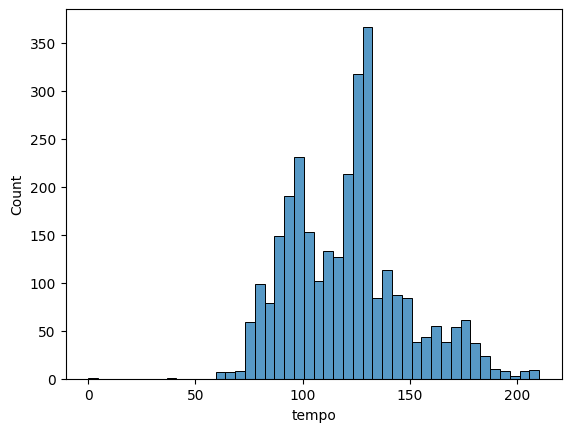

In [36]:
sns.histplot(spotify_sample['tempo'])


Чтобы гистограмма была подробнее, можно увеличить количество корзин (`bins`).


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(spotify_sample['tempo'], bins=50, ax=ax)


Можно построить горизонтальную гистограмму, передав данные в ось `y` вместо `x`.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(y=spotify_sample['tempo'], bins=50, ax=ax)


Можно наложить несколько гистограмм друг на друга с помощью `hue`. Чтобы они не перекрывались слишком сильно, используют `element='step'` или `element='poly'`.


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.histplot(
    data=spotify_sample[spotify_sample['playlist_genre'].isin(['edm', 'rock'])],
    x='tempo',
    hue='playlist_genre',
    element='step'
)


Метод `sns.displot()` — это универсальная обертка над гистограммами. С его помощью можно легко добавить ядерную оценку плотности (`kde=True`).


In [ ]:
sns.displot(
    data=spotify_sample[spotify_sample['playlist_genre'].isin(['edm', 'rock'])],
    x='tempo',
    hue='playlist_genre',
    kde=True,
    height=6,
    aspect=1.5
)


Более того, можно построить эмпирически найденную функцию распределения (ECDF). Для этого указывается `kind='ecdf'`.


In [ ]:
sns.displot(
    data=spotify_sample[spotify_sample['playlist_genre'].isin(['edm', 'rock'])],
    x='tempo',
    hue='playlist_genre',
    kind='ecdf',
    height=6,
    aspect=1.5
)


---
### 6. Попарные графики и метод pairplot

Часто бывает полезно посмотреть на все попарные зависимости признаков сразу. Для этого есть метод `sns.pairplot()`. По диагонали он строит распределения каждого признака, а вне диагонали — scatter plots для всех пар признаков.


In [ ]:
# Возьмем небольшой набор фичей и 3 жанра
subset = spotify_sample[spotify_sample['playlist_genre'].isin(['edm', 'rock', 'latin'])]
features = ['danceability', 'energy', 'acousticness', 'playlist_genre']

sns.pairplot(subset[features])


Здесь тоже можно добавить `hue`, чтобы раскрасить точки по категориям и оценить, насколько хорошо жанры разделимы по этим фичам.


In [ ]:
sns.pairplot(
    subset[features],
    hue='playlist_genre',
    palette='Set2'
)
